# 01 — Explore FRED data and verify the data inputs

**Initial data and API checks.** This notebook verifies that the project's FRED connection is working, inspects the series manifest, exercises the main FRED client functions, and checks the basic structure and dating conventions of the core series used in the analysis.

## 1. Check the API connections

The check below confirms that the required API credentials are available without exposing their values.

In [1]:
import os

from dotenv import load_dotenv

load_dotenv()

for key_name in ["FRED_API_KEY", "EIA_API_KEY"]:
    value = os.environ.get(key_name)
    status = f"set (length={len(value)})" if value else "MISSING"
    print(f"{key_name}: {status}")

FRED_API_KEY: set (length=32)
EIA_API_KEY: set (length=40)


## 2. Inspect the series manifest

The series manifest defines which FRED series are used in the project and records their role, frequency, and other metadata. The table below provides a quick check of the configured data inputs.

In [2]:
import pandas as pd

from src.series_manifest import SERIES

manifest_df = pd.DataFrame.from_dict(SERIES, orient="index").rename_axis("series_id").reset_index()
manifest_df

,series_id,kind,freq,role,benchmark,fuel,hub,formulation,region
0,WCOILWTICO,crude,weekly-fri,core,WTI,NaN,NaN,NaN,NaN
1,DCOILWTICO,crude,daily,core,WTI,NaN,NaN,NaN,NaN
2,WCOILBRENTEU,crude,weekly-fri,robustness,Brent,NaN,NaN,NaN,NaN
3,DCOILBRENTEU,crude,daily,robustness,Brent,NaN,NaN,NaN,NaN
4,WGASUSGULF,spot,weekly-fri,core,NaN,gasoline,Gulf Coast,conventional,NaN
5,DGASUSGULF,spot,daily,core,NaN,gasoline,Gulf Coast,conventional,NaN
6,WGASNYH,spot,weekly-fri,regional,NaN,gasoline,NY Harbor,conventional,NaN
7,DGASNYH,spot,daily,regional,NaN,gasoline,NY Harbor,conventional,NaN
8,WRGASLA,spot,weekly-fri,regional,NaN,gasoline,Los Angeles,RBOB,NaN
9,DRGASLA,spot,daily,regional,NaN,gasoline,Los Angeles,RBOB,NaN


In [3]:
print("--- by kind ---")
print(manifest_df["kind"].value_counts())
print("\n--- by freq ---")
print(manifest_df["freq"].value_counts())
print("\n--- by role ---")
print(manifest_df["role"].value_counts())

--- by kind ---
kind
retail    13
spot      12
crude      4
Name: count, dtype: int64

--- by freq ---
freq
weekly-mon    13
weekly-fri     8
daily          8
Name: count, dtype: int64

--- by role ---
role
comparison    12
regional       9
core           5
robustness     3
Name: count, dtype: int64


## 3. Validate the FRED client

The main functions used to retrieve FRED data are checked below using representative calls. The outputs are inspected for structure, data types, dimensions, and date coverage where applicable.

### 3a. Series observations

In [4]:
from IPython.display import display
from src.fred_client import get_series

wti = get_series("WCOILWTICO")
print(f"WTI shape: {wti.shape}")
print(f"Types:\n{wti.dtypes}")
print(f"Date range: {wti['date'].min().date()} to {wti['date'].max().date()}")
display(wti.head())


WTI shape: (2122, 2)
Types:
date     datetime64[us]
value           float64
dtype: object
Date range: 1986-01-03 to 2026-08-28


,date,value
0,1986-01-03,25.78
1,1986-01-10,25.99
2,1986-01-17,24.57
3,1986-01-24,20.31
4,1986-01-31,19.69


### 3b. List release series

Release 212, "Petroleum and Other Liquids," is the wholesale-spot release this project draws
from.

In [5]:
from src.fred_client import list_release_series

release_212 = list_release_series(212)

print(f"Release 212 shape: {release_212.shape}")
print(f"Types:\n{release_212.dtypes}")
# No single "date" column here — the closest equivalent is the earliest observation_start
# and latest observation_end across every series the release contains.
print(f"Date range:\nobservation_start min: {release_212['observation_start'].min()}\nobservation_end max:   {release_212['observation_end'].max()}")

Release 212 shape: (44, 5)
Types:
series_id            str
title                str
frequency            str
observation_start    str
observation_end      str
dtype: object
Date range:
observation_start min: 1986-01-01
observation_end max:   2026-09-01


In [6]:
release_212.head()

,series_id,title,frequency,observation_start,observation_end
0,ACOILBRENTEU,Crude Oil Prices: Brent - Europe,Annual,1987-01-01,2025-01-01
1,ACOILWTICO,Crude Oil Prices: West Texas Intermediate (WTI...,Annual,1986-01-01,2025-01-01
2,ADFUELLA,Ultra-Low-Sulfur No. 2 Diesel Fuel Prices: Los...,Annual,2001-01-01,2025-01-01
3,ADFUELNYH,Ultra-Low-Sulfur No. 2 Diesel Fuel Prices: New...,Annual,2006-01-01,2025-01-01
4,ADFUELUSGULF,Ultra-Low-Sulfur No. 2 Diesel Fuel Prices: U.S...,Annual,2006-01-01,2025-01-01


### 3c. Series metadata

In [7]:
from src.fred_client import get_series_info

get_series_info("WCOILWTICO")

{'id': 'WCOILWTICO',
 'realtime_start': '2026-09-04',
 'realtime_end': '2026-09-04',
 'title': 'Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma',
 'observation_start': '1986-01-03',
 'observation_end': '2026-08-28',
 'frequency': 'Weekly, Ending Friday',
 'frequency_short': 'W',
 'units': 'Dollars per Barrel',
 'units_short': '$ per Barrel',
 'seasonal_adjustment': 'Not Seasonally Adjusted',
 'seasonal_adjustment_short': 'NSA',
 'last_updated': '2026-09-02 12:17:27-05',
 'popularity': 41,
 'notes': 'Definitions, Sources and Explanatory Notes: http://www.eia.doe.gov/dnav/pet/TblDefs/pet_pri_spt_tbldef2.asp'}

## 4. Core series

These are the three core series used to represent the crude-to-wholesale-to-retail transmission chain: `WCOILWTICO` (crude), `WGASUSGULF` (wholesale spot gasoline), and `GASREGW` (retail gasoline).

The last five observations are shown together with a day-of-week check to verify the dating convention used by each series. Crude and wholesale spot are expected to be Friday-dated, while retail gasoline is Monday-dated.

In [8]:
from src.fred_client import get_series

core_series = {
    "WCOILWTICO": wti,  # already pulled in §3a — no need to re-fetch
    "WGASUSGULF": get_series("WGASUSGULF"),
    "GASREGW": get_series("GASREGW"),
}

for series_id, df in core_series.items():
    print(f"--- {series_id} ---\n\tlast 5 rows:")
    display(df.tail())
    print(f"\n\tday-of-week counts:")
    print(df["date"].dt.day_name().value_counts(), "\n")

--- WCOILWTICO ---
	last 5 rows:


,date,value
2117,2026-07-31,84.51
2118,2026-08-07,78.94
2119,2026-08-14,84.05
2120,2026-08-21,87.35
2121,2026-08-28,84.62



	day-of-week counts:
date
Friday    2122
Name: count, dtype: int64 

--- WGASUSGULF ---
	last 5 rows:


,date,value
2095,2026-07-31,3.417
2096,2026-08-07,2.992
2097,2026-08-14,3.193
2098,2026-08-21,3.436
2099,2026-08-28,3.564



	day-of-week counts:
date
Friday    2100
Name: count, dtype: int64 

--- GASREGW ---
	last 5 rows:


,date,value
1876,2026-08-03,4.079
1877,2026-08-10,4.006
1878,2026-08-17,4.049
1879,2026-08-24,4.085
1880,2026-08-31,4.071



	day-of-week counts:
date
Monday    1881
Name: count, dtype: int64 



The series are shown in their native units \$/barrel for crude and \$/gallon for gasoline. This plot is intended as a structural check rather than a direct comparison of magnitudes.

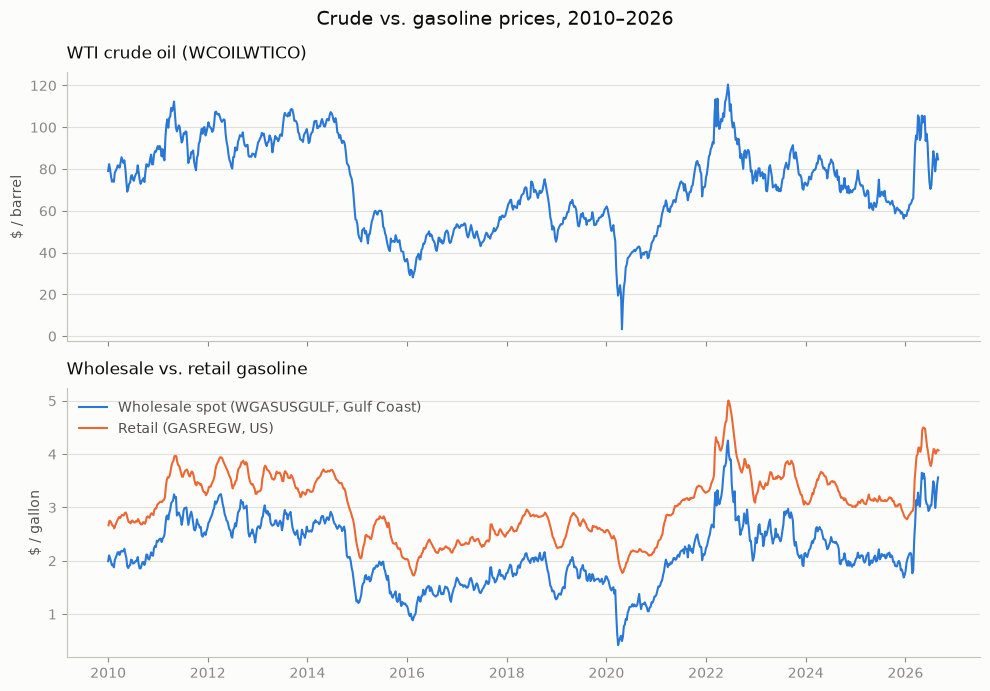

In [9]:
import matplotlib.pyplot as plt

PLOT_START = "2010-01-01"

crude = core_series["WCOILWTICO"]
crude = crude[crude["date"] >= PLOT_START]
wholesale = core_series["WGASUSGULF"]
wholesale = wholesale[wholesale["date"] >= PLOT_START]
retail = core_series["GASREGW"]
retail = retail[retail["date"] >= PLOT_START]

fig, (ax_crude, ax_gas) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, facecolor="#fcfcfb")

for ax in (ax_crude, ax_gas):
    ax.set_facecolor("#fcfcfb")
    ax.tick_params(colors="#898781")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#c3c2b7")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

ax_crude.plot(crude["date"], crude["value"], color="#2a78d6", linewidth=1.5)
ax_crude.set_title("WTI crude oil (WCOILWTICO)", color="#0b0b0b", fontsize=12, pad=10, loc="left")
ax_crude.set_ylabel("$ / barrel", color="#52514e")

ax_gas.plot(wholesale["date"], wholesale["value"], color="#2a78d6", linewidth=1.5, label="Wholesale spot (WGASUSGULF, Gulf Coast)")
ax_gas.plot(retail["date"], retail["value"], color="#eb6834", linewidth=1.5, label="Retail (GASREGW, US)")
ax_gas.set_title("Wholesale vs. retail gasoline", color="#0b0b0b", fontsize=12, pad=10, loc="left")
ax_gas.set_ylabel("$ / gallon", color="#52514e")
ax_gas.legend(frameon=False, labelcolor="#52514e")

fig.suptitle("Crude vs. gasoline prices, 2010\u20132026", color="#0b0b0b", fontsize=14)
plt.tight_layout()
plt.show()